In [ ]:
!pip install qiskit qiskit_aer numpy scipy pylatexenc qiskit-algorithms qiskit-nature qiskit-ibm-runtime pyscf qiskit-nature[pyscf]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━

In [ ]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import TwoLocal
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper,ParityMapper,TaperedQubitMapper
from qiskit_algorithms.optimizers import SPSA,COBYLA,L_BFGS_B,SLSQP
from qiskit_nature.second_q.circuit.library import UCCSD,HartreeFock,UCC
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel,depolarizing_error
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeCairoV2
from qiskit.primitives import BackendEstimatorV2
from qiskit import transpile
from qiskit.quantum_info import Statevector

In [ ]:
estimator=Estimator()

In [ ]:
driver=PySCFDriver(
    atom='H 0 0 0 ; H 0 0 0.735',
    basis='sto3g'
)

problem=driver.run()
hamiltonian=problem.hamiltonian
second_q_hamiltonian=hamiltonian.second_q_op()

mapper=JordanWignerMapper()
full_hamiltonian=mapper.map(second_q_hamiltonian)
print(full_hamiltonian)

SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])


In [ ]:

he=[]
hd=[]

for p,c in full_hamiltonian.to_list():
    if 'X' in p or 'Y' in p:
        hd.append((p,c))
    else:
        he.append((p,c))

partial_hamiltonian = SparsePauliOp.from_list(he)
hard_hamiltonian    = SparsePauliOp.from_list(hd)

In [ ]:
print(f"Full Hamiltonian  — number of terms:", full_hamiltonian)
print("Partial Hamiltonian (I/Z only) terms:", (he))
print("Hard Hamiltonian  (X/Y)  terms      :", (hd))

Full Hamiltonian  — number of terms: SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])
Partial Hamiltonian (I/Z only) terms: [('IIII', (-0.8105479805373275+0j)), ('IIIZ', (0.17218393261915566+0j)), ('IIZI', (-0.22575349222402394+0j)), ('IZII', (0.1721839326191556+0j)), ('ZIII', (-0.2257534922240239+0j)), ('IIZZ', (0.12091263261776623+0j)), ('IZIZ', (0.16892753870087907+0j)), ('ZIIZ', (0.16614543256382408+0j)), ('IZZI', (0.16614543256382408+0j)), ('ZIZI', (0.17464343068300453+0j)), ('ZZII', (0.12091263261776623+0j))]
Hard Hamiltonian  (X/Y)  terms      : [('YYYY', (0.04523279994605784+0j)), ('XXYY', (0.04523279994605784+0j)), 

In [ ]:
print("Full Hamiltonian  — number of terms:", len(full_hamiltonian))
print("Partial Hamiltonian (I/Z only) terms:", len(he))
print("Hard Hamiltonian  (X/Y)  terms      :", len(hd))

Full Hamiltonian  — number of terms: 15
Partial Hamiltonian (I/Z only) terms: 11
Hard Hamiltonian  (X/Y)  terms      : 4


In [ ]:
initial_state=HartreeFock(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper
)
print(initial_state)


     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
     ┌───┐
q_2: ┤ X ├
     └───┘
q_3: ─────
          


In [ ]:
def hf_state_h2():
    sv = np.zeros(16, dtype=complex)
    sv[12] = 1.0
    return sv

In [ ]:

def fit_refined_operator_h11(hd_op, refined_pauli="ZIZI", delta_theta=0.1, n_qubits=4):

    np.random.seed(42)
    hf_sv = Statevector(hf_state_h2())

    refined_op = SparsePauliOp.from_list([(refined_pauli, 1.0)])

    numerator   = 0.0
    denominator = 0.0
    n_points    = 5

    for _ in range(n_points):
        delta = delta_theta * (2 * np.random.rand(2**n_qubits) - 1)
        delta_sv = Statevector(hf_sv.data + delta * 1j * hf_sv.data)
        delta_sv = Statevector(delta_sv.data / np.linalg.norm(delta_sv.data))

        exp_hd      = np.real(delta_sv.expectation_value(hd_op))
        exp_refined = np.real(delta_sv.expectation_value(refined_op))

        if abs(exp_refined) > 1e-10:
            numerator   += exp_hd
            denominator += exp_refined

    c1 = numerator / denominator
    return c1

c1 = fit_refined_operator_h11(hard_hamiltonian)
print(f"\nFitted coefficient for H'_d^{{11}} (ZIZI): {c1:.5f}")
print(f"  Paper value (Table II): -0.03594")



Fitted coefficient for H'_d^{11} (ZIZI): -0.00000
  Paper value (Table II): -0.03594


In [ ]:
''' we use the paper's reference for the coefficeint'''

refined_hd=SparsePauliOp.from_list([("ZIZI",-0.03594)])
refined_partial_hamiltonian=(partial_hamiltonian+refined_hd).simplify()


In [ ]:
numpy_solver  = NumPyMinimumEigensolver()
numpy_result  = numpy_solver.compute_minimum_eigenvalue(full_hamiltonian)
exact_energy_h2  = float(numpy_result.eigenvalue.real)
print(f"\nExact (NumPy) ground-state energy: {exact_energy_h2:.8f} Ha")


Exact (NumPy) ground-state energy: -1.85727503 Ha


In [ ]:
class EnergyCallback:
    def __init__(self):
        self.values = []

    def __call__(self, nfev, params, value, meta):
        self.values.append(float(value))


In [ ]:
initial_state=HartreeFock(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper
)
ansatz=UCCSD(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
    initial_state=initial_state
)

In [ ]:
fh_callback_h2=EnergyCallback()

full_vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(),
    callback=fh_callback_h2
)

fh_result=full_vqe.compute_minimum_eigenvalue(full_hamiltonian).eigenvalue.real
print(fh_result)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-1.8572750301871297


In [ ]:
sharc_callback_h2 = EnergyCallback()

sharc_vqe    = VQE(estimator=estimator,
                   ansatz=ansatz,
                   optimizer=L_BFGS_B(maxiter=100)
                   , callback=sharc_callback_h2)
sharc_result = sharc_vqe.compute_minimum_eigenvalue(refined_partial_hamiltonian)
sharc_params = sharc_result.optimal_parameters


corrected_hamiltonian=(refined_partial_hamiltonian+hard_hamiltonian-refined_hd).simplify()

bound_circuit=ansatz.assign_parameters(sharc_params)
sv_sharc      = Statevector(bound_circuit)
sharc_energy_raw  = float(np.real(sv_sharc.expectation_value(refined_partial_hamiltonian)))
sharc_energy_corr_h2 = float(np.real(sv_sharc.expectation_value(corrected_hamiltonian)))

print(f"\nSHARC-VQE optimization energy    : {sharc_energy_raw:.8f} Ha  (H_p^{{11}})")
print(f"SHARC-VQE corrected energy (Eq17): {sharc_energy_corr_h2:.8f} Ha")
print(f"SHARC-VQE iterations             : {len(sharc_callback_h2.values)}")



/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



SHARC-VQE optimization energy    : -1.87290799 Ha  (H_p^{11})
SHARC-VQE corrected energy (Eq17): -1.83696802 Ha
SHARC-VQE iterations             : 36


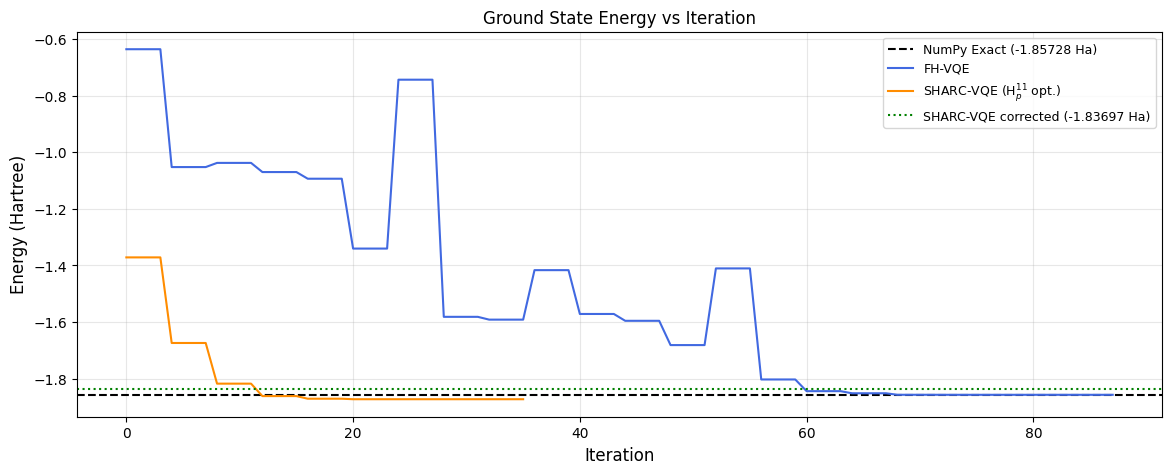

In [ ]:
plt.figure(figsize=(14, 5))
plt.axhline(exact_energy_h2, color="black", linestyle="--", linewidth=1.5, label=f"NumPy Exact ({exact_energy_h2:.5f} Ha)")
plt.plot(fh_callback_h2.values,    color="royalblue",  linewidth=1.5, label="FH-VQE")
plt.plot(sharc_callback_h2.values, color="darkorange",  linewidth=1.5, label="SHARC-VQE (H$_p^{11}$ opt.)")
plt.axhline(sharc_energy_corr_h2, color="green", linestyle=":", linewidth=1.5,
            label=f"SHARC-VQE corrected ({sharc_energy_corr_h2:.5f} Ha)")
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Energy (Hartree)", fontsize=12)
plt.title("Ground State Energy vs Iteration", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# noisy

NoiseModel:
  Basis gates: ['cx', 'delay', 'id', 'measure', 'reset', 'rz', 'sx', 'x']
  Instructions with noise: ['sx', 'measure', 'cx', 'x', 'id']
  Qubits with noise: [0, 1, 2, 3, 4]
  Specific qubit errors: [('cx', (0, 1)), ('cx', (1, 2)), ('cx', (2, 3)), ('cx', (3, 4)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('id', (4,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('sx', (4,)), ('x', (0,)), ('x', (1,)), ('x', (2,)), ('x', (3,)), ('x', (4,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('measure', (4,))]
Noisy Ground Energy:
-1.5202901437428957


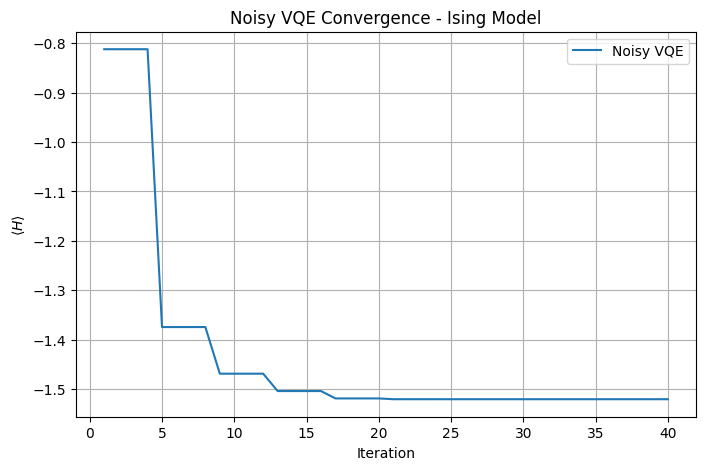

In [ ]:
# ===========================
# Imports
# ===========================

import numpy as np
import matplotlib.pyplot as plt

from qiskit.compiler import transpile

from qiskit.quantum_info import SparsePauliOp

from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.noise import NoiseModel

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import L_BFGS_B



# ===========================
# 1. Define Generic Backend
# ===========================

coupling_map = [
    (0,1),
    (1,2),
    (2,3),
    (3,4)
]


device = GenericBackendV2(
    num_qubits=5,
    coupling_map=coupling_map
)


# Create noise model from fake device
noise_model = NoiseModel.from_backend(device)


print(noise_model)



# ===========================
# 2. Noisy Aer Estimator
# ===========================

noisy_estimator = AerEstimator(
    options={
        "backend_options": {
            "method": "density_matrix",
            "noise_model": noise_model,
            "coupling_map": coupling_map
        }
    }
)



# ===========================
# 3. Transpile Ansatz
# ===========================

transpiled_ansatz = transpile(
    ansatz,
    backend=device,
    initial_layout=[0, 1, 2, 3],
    optimization_level=1
)



# ===========================
# 4. VQE Callback
# ===========================

values_noisy = []
counts_noisy = []


def callback(eval_count, parameters, mean, metadata):

    values_noisy.append(mean)
    counts_noisy.append(eval_count)



# ===========================
# 5. VQE
# ===========================

optimizer = L_BFGS_B(
    maxiter=100
)


vqe_noisy = VQE(
    estimator=noisy_estimator,
    ansatz=transpiled_ansatz,
    optimizer=optimizer,
    callback=callback
)



# ===========================
# 6. Run VQE
# ===========================

result = vqe_noisy.compute_minimum_eigenvalue(
    refined_partial_hamiltonian
)


energy_noisy = result.eigenvalue.real


print("Noisy Ground Energy:")
print(energy_noisy)



# ===========================
# 7. Plot Convergence
# ===========================

plt.figure(figsize=(8,5))

plt.plot(
    counts_noisy,
    values_noisy,
    label="Noisy VQE"
)

plt.xlabel("Iteration")
plt.ylabel(r"$\langle H \rangle$")
plt.title("Noisy VQE Convergence - Ising Model")

plt.grid()
plt.legend()

plt.show()

In [ ]:
params=result.optimal_parameters

In [ ]:

corrected_hamiltonian=(refined_partial_hamiltonian+hard_hamiltonian-refined_hd).simplify()

bound_circuit=transpiled_ansatz.assign_parameters(result.optimal_parameters)
sv_sharc      = Statevector(bound_circuit)


from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix

# 1. Take your bound circuit and tell Aer to save the noisy density matrix
circuit_for_noisy_energy = bound_circuit.copy()
circuit_for_noisy_energy.save_density_matrix()

# 2. Run it through the AerSimulator using your exact noise model
sim = AerSimulator(
    method="density_matrix",
    noise_model=noise_model,
    coupling_map=coupling_map
)
sim_result = sim.run(circuit_for_noisy_energy, shots=1).result()

# This is the TRUE noisy density matrix (corrupted by the hardware noise)
noisy_density_matrix = DensityMatrix(sim_result.data(0)["density_matrix"])

# 3. Compute expectation values using the noisy density matrix instead of Statevector
true_noisy_energy_raw = float(np.real(noisy_density_matrix.expectation_value(refined_partial_hamiltonian)))
true_noisy_energy_corr = float(np.real(noisy_density_matrix.expectation_value(corrected_hamiltonian)))

print(f"\nTRUE Noisy Expectation Value (Raw)      : {true_noisy_energy_raw:.8f} Ha")
print(f"TRUE Noisy Expectation Value (Corrected): {true_noisy_energy_corr:.8f} Ha")



TRUE Noisy Expectation Value (Raw)      : -1.52029014 Ha
TRUE Noisy Expectation Value (Corrected): -1.49364989 Ha


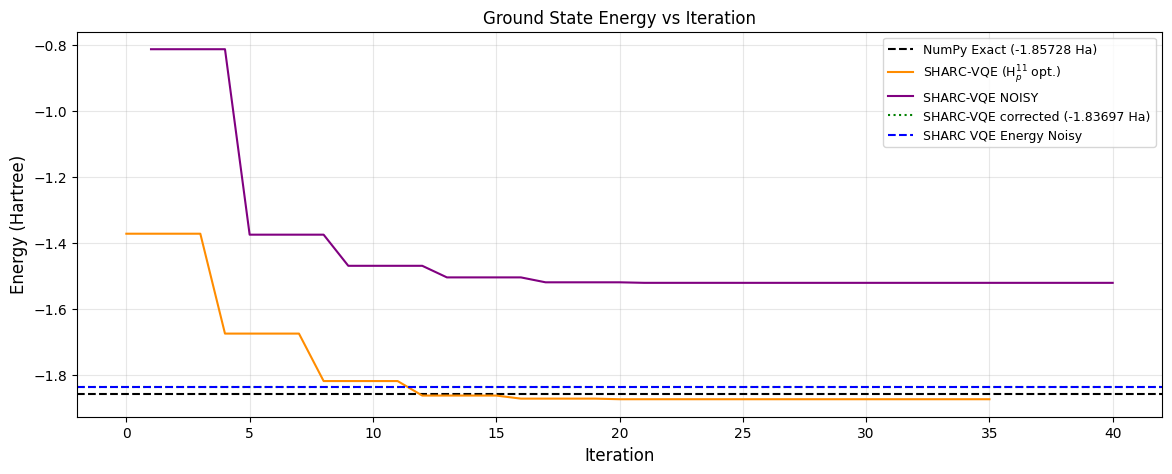

In [ ]:
plt.figure(figsize=(14, 5))
plt.axhline(exact_energy_h2, color="black", linestyle="--", linewidth=1.5, label=f"NumPy Exact ({exact_energy_h2:.5f} Ha)")
plt.plot(sharc_callback_h2.values, color="darkorange",  linewidth=1.5, label="SHARC-VQE (H$_p^{11}$ opt.)")
plt.plot(counts_noisy,values_noisy,color='purple',linewidth=1.5, label="SHARC-VQE NOISY")
plt.axhline(sharc_energy_corr_h2, color="green", linestyle=":", linewidth=1.5,
            label=f"SHARC-VQE corrected ({sharc_energy_corr_h2:.5f} Ha)")
plt.axhline(sharc_energy_corr_h2,color='blue',lw=1.5,linestyle='--',label='SHARC VQE Energy Noisy')
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Energy (Hartree)", fontsize=12)
plt.title("Ground State Energy vs Iteration", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
driver=PySCFDriver(
    atom='Li 0 0 0 ;H 0 0 1.595',
    basis='sto3g'
)

problem=driver.run()
hamiltonian=problem.hamiltonian
second_q_hamiltonian=hamiltonian.second_q_op()

mapper=JordanWignerMapper()

transformer=ActiveSpaceTransformer(num_electrons=2,num_spatial_orbitals=3)
reduced_problem=transformer.transform(problem)
reduced_hamiltonian=reduced_problem.hamiltonian.second_q_op()

hamiltonian=mapper.map(reduced_hamiltonian)
print(hamiltonian)

SparsePauliOp(['IIIIII', 'IIIIIZ', 'IIIIYY', 'IIIIXX', 'IIIIZI', 'IIIZII', 'IIZIII', 'IYYIII', 'IXXIII', 'IZIIII', 'ZIIIII', 'IIIIZZ', 'IIIZIZ', 'IIZIIZ', 'IYYIIZ', 'IXXIIZ', 'IZIIIZ', 'ZIIIIZ', 'IIIZYY', 'IIIZXX', 'IIZIYY', 'IIZIXX', 'IYYIYY', 'IXXIYY', 'IYYIXX', 'IXXIXX', 'IZIIYY', 'IZIIXX', 'ZIIIYY', 'ZIIIXX', 'YZYYZY', 'XZXYZY', 'YZYXZX', 'XZXXZX', 'YYIYZY', 'XXIYZY', 'YYIXZX', 'XXIXZX', 'IIIZZI', 'IIZIZI', 'IYYIZI', 'IXXIZI', 'IZIIZI', 'ZIIIZI', 'YZYYYI', 'XZXYYI', 'YZYXXI', 'XZXXXI', 'YYIYYI', 'XXIYYI', 'YYIXXI', 'XXIXXI', 'IIZZII', 'IYYZII', 'IXXZII', 'IZIZII', 'ZIIZII', 'IZZIII', 'ZIZIII', 'ZYYIII', 'ZXXIII', 'ZZIIII'],
              coeffs=[-0.46109435+0.j,  0.02679298+0.j,  0.01201659+0.j,  0.01201659+0.j,
 -0.14567362+0.j, -0.16154151+0.j,  0.02679298+0.j,  0.01201659+0.j,
  0.01201659+0.j, -0.14567362+0.j, -0.16154151+0.j,  0.05268478+0.j,
  0.06174201+0.j,  0.12191446+0.j,  0.01212374+0.j,  0.01212374+0.j,
  0.05593827+0.j,  0.06760454+0.j,  0.00338993+0.j,  0.00338993+0.j

In [ ]:
print(len(hamiltonian))

62


In [ ]:
he=[]
hd=[]

for p,c in hamiltonian.to_list():
    if 'X' in p or 'Y ' in p:
        hd.append((p,c))
    else:
        he.append((p,c))

partial_hamiltonian = SparsePauliOp.from_list(he)
hard_hamiltonian    = SparsePauliOp.from_list(hd)

In [ ]:
print(len(partial_hamiltonian))
print(len(hard_hamiltonian))

37
25


In [ ]:
initial_state=HartreeFock(
    reduced_problem.num_spatial_orbitals,
    reduced_problem.num_particles,
    mapper
)
print(initial_state)

     ┌───┐
q_0: ┤ X ├
     └───┘
q_1: ─────
          
q_2: ─────
     ┌───┐
q_3: ┤ X ├
     └───┘
q_4: ─────
          
q_5: ─────
          


In [ ]:
def sv():
    sv=np.zeros(64,dtype=complex)
    sv[9]=1.0
    return sv

In [ ]:
def coefficent_generetor(hd,n_qubits=6,refined_pauli='ZZIZZI',delta_theta=0.1):
    np.random.seed(42)
    numerator=0.0
    denominator=0.0
    n=5

    hf_sv=Statevector(sv())
    refined_operator = SparsePauliOp.from_list([(refined_pauli, 1.0)])

    for _ in range(n):
        delta = delta_theta * (2 * np.random.rand(2**n_qubits) - 1)
        delta_sv = Statevector(hf_sv.data + delta * 1j * hf_sv.data)
        delta_sv = Statevector(delta_sv.data / np.linalg.norm(delta_sv.data))

        exp_hd      = np.real(delta_sv.expectation_value(hd))
        exp_refined = np.real(delta_sv.expectation_value(refined_operator))

        if abs(exp_refined) > 1e-10:
            numerator   += exp_hd
            denominator += exp_refined

    c1 = numerator / denominator


    for _ in range(n):
        elta = 2*delta_theta * (2 * np.random.rand(2**n_qubits) - 1)
        delta_sv = Statevector(hf_sv.data + delta * 1j * hf_sv.data)
        delta_sv = Statevector(delta_sv.data / np.linalg.norm(delta_sv.data))

        exp_hd      = np.real(delta_sv.expectation_value(hd))
        exp_refined = np.real(delta_sv.expectation_value(refined_operator))

        if abs(exp_refined) > 1e-10:
            numerator   += exp_hd
            denominator += exp_refined

    c2 = numerator / denominator


    coeff=(c1+c2)/2

    return coeff

In [ ]:
coeff=coefficent_generetor(hard_hamiltonian)
print(coeff)

0.0


In [ ]:
refined_hd=SparsePauliOp.from_list([("ZZIZZI",coeff)])
refined_partial_hamiltonian=(partial_hamiltonian+refined_hd).simplify()

In [ ]:
nuclear_repulsion = reduced_problem.hamiltonian.constants.get("nuclear_repulsion_energy", 0.0)
energy_shift = reduced_problem.hamiltonian.constants.get("ActiveSpaceTransformer", 0.0)
print(nuclear_repulsion)
print(energy_shift)
constant_shift = nuclear_repulsion + energy_shift
print(constant_shift)

0.995317638094044
-7.798291188105951
-6.802973550011907


In [ ]:
solver=NumPyMinimumEigensolver()
solve=solver.compute_minimum_eigenvalue(hamiltonian)
result_vqe_lih=float(solve.eigenvalue.real)+constant_shift
print(result_vqe_lih)

-7.863077753982225


In [ ]:
class EnergyCallback:
    def __init__(self):
        self.values = []

    def __call__(self, nfev, params, value, meta):
        self.values.append(float(value))

In [ ]:
vqe_callback_lih=EnergyCallback()


ansatz=UCCSD(
    reduced_problem.num_spatial_orbitals,
    reduced_problem.num_particles,
    mapper,
    initial_state=initial_state
)

full_vqe=VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(),
    callback=vqe_callback_lih
)


In [ ]:
vqe_energy_lih=full_vqe.compute_minimum_eigenvalue(hamiltonian).eigenvalue.real+constant_shift
print(vqe_energy_lih)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-7.863055332059831


In [ ]:
vqe_energies_lih=[raw+constant_shift for raw in vqe_callback_lih.values]

In [ ]:
sharc_callback_lih = EnergyCallback()

sharc_vqe    = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=L_BFGS_B(maxiter=100),
    callback=sharc_callback_lih
)

sharc_vqe_energy_lih=sharc_vqe.compute_minimum_eigenvalue(refined_partial_hamiltonian)
params=sharc_vqe_energy_lih.optimal_parameters

ansatz=ansatz.assign_parameters(params)
corrected_hamiltonian=(refined_partial_hamiltonian+hard_hamiltonian-refined_hd).simplify()
sv_sharc      = Statevector(ansatz)
sharc_energy_corr_lih = float(np.real(sv_sharc.expectation_value(corrected_hamiltonian)))+constant_shift
print(sharc_energy_corr_lih)

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


-7.862388302410234


In [ ]:
sharc_energies_lih=[raw+constant_shift for raw in sharc_callback_lih.values]

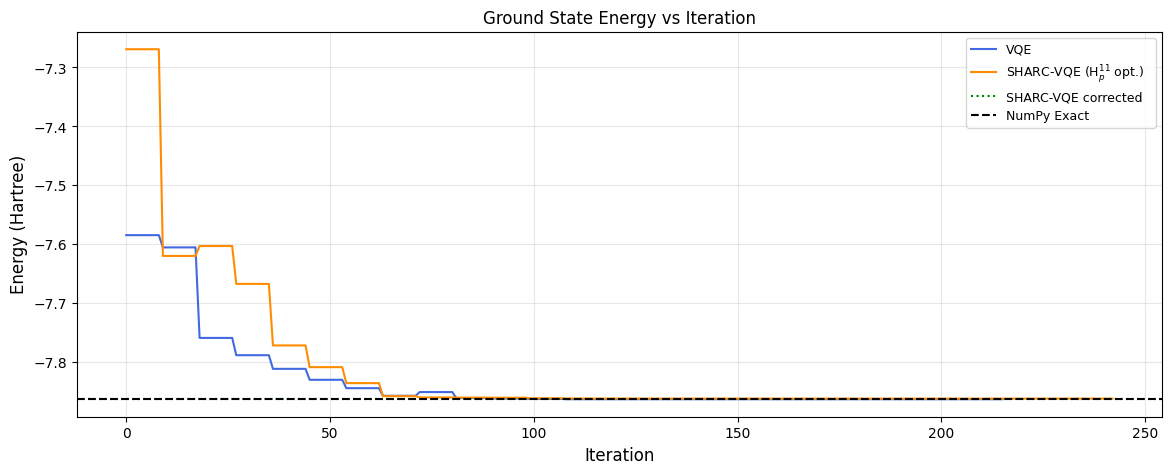

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(vqe_energies_lih, color="royalblue",  linewidth=1.5, label="VQE")
plt.plot(sharc_energies_lih, color="darkorange",  linewidth=1.5, label="SHARC-VQE (H$_p^{11}$ opt.)")
plt.axhline(sharc_energy_corr_lih, color="green", linestyle=":", linewidth=1.5,
            label=f"SHARC-VQE corrected  ")
plt.axhline(result_vqe_lih, color="black", linestyle="--", linewidth=1.5, label=f"NumPy Exact")
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Energy (Hartree)", fontsize=12)
plt.title("Ground State Energy vs Iteration", fontsize=12)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()